In [1]:
from mnist_classifier import MNISTClassifier

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


# MNIST Digit Recognizer: Machine Learning Pipeline
## Exploratory Data Analysis (EDA)

In this section, we will load the Kaggle MNIST dataset and visualize it to understand the distribution of our classes and the natural variance in human handwriting.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots render directly below the code cells
%matplotlib inline

# Load the data
print("Loading dataset...")
df = pd.read_csv("train.csv")

# Separate labels from pixel features
y = df['label']
X = df.drop('label', axis=1)

print(f"Dataset loaded! Total images: {len(X)}")
print(f"Number of features (pixels) per image: {X.shape[1]}")

Loading dataset...
Dataset loaded! Total images: 42000
Number of features (pixels) per image: 784


### 1.1 Class Distribution
First, we need to check if our dataset is balanced. If we have significantly more of one digit than others, our models might become biased.

/tmp/ipykernel_3317984/157988263.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="viridis")


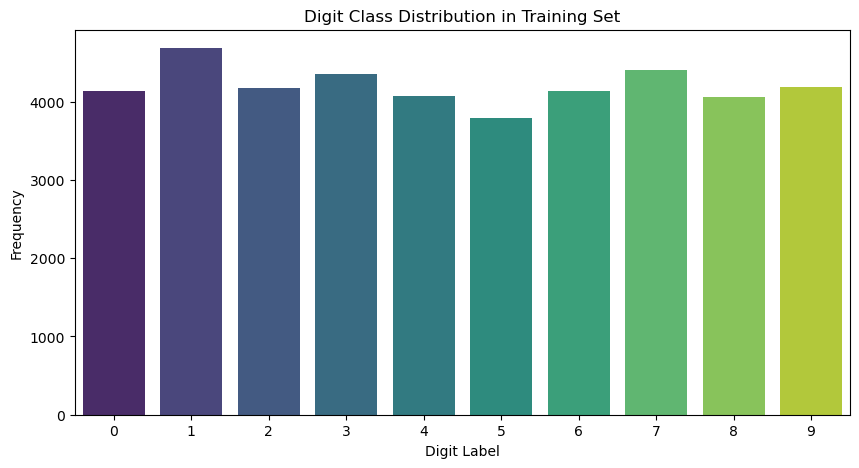

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(x=y, palette="viridis")
plt.title("Digit Class Distribution in Training Set")
plt.xlabel("Digit Label")
plt.ylabel("Frequency")
plt.show()

### 1.2 Visualizing the Digits
To understand the complexity of the problem, let's look at a random sample of the handwritten digits. This shows us the natural variance (e.g., how differently people draw the number '7' or '4').

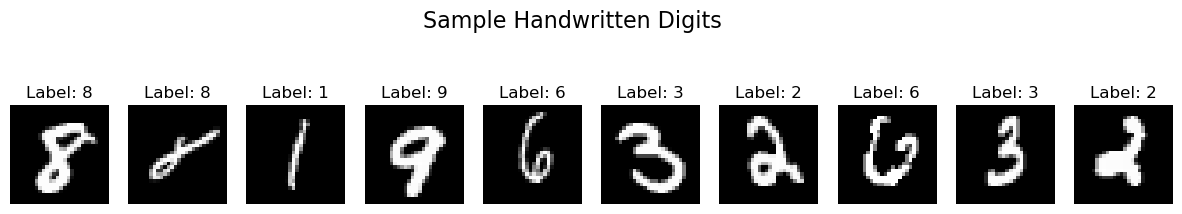

In [4]:
plt.figure(figsize=(15, 3))

# Pick 10 random indices
num_digits = 10
random_indices = np.random.randint(0, len(X), num_digits)

for i, idx in enumerate(random_indices):
    plt.subplot(1, num_digits, i + 1)
    # Reshape the 784 pixels back into a 28x28 grid
    image = X.iloc[idx].values.reshape(28, 28)
    
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {y.iloc[idx]}")
    plt.axis('off')
    
plt.suptitle("Sample Handwritten Digits", fontsize=16)
plt.show()

### 1.3 The "Average" Digit
By calculating the mean pixel intensity across all images of a specific digit, we can see the "fuzzy" prototype of each number. Digits that are blurrier (like 8 or 9) have higher variance in how they are written.

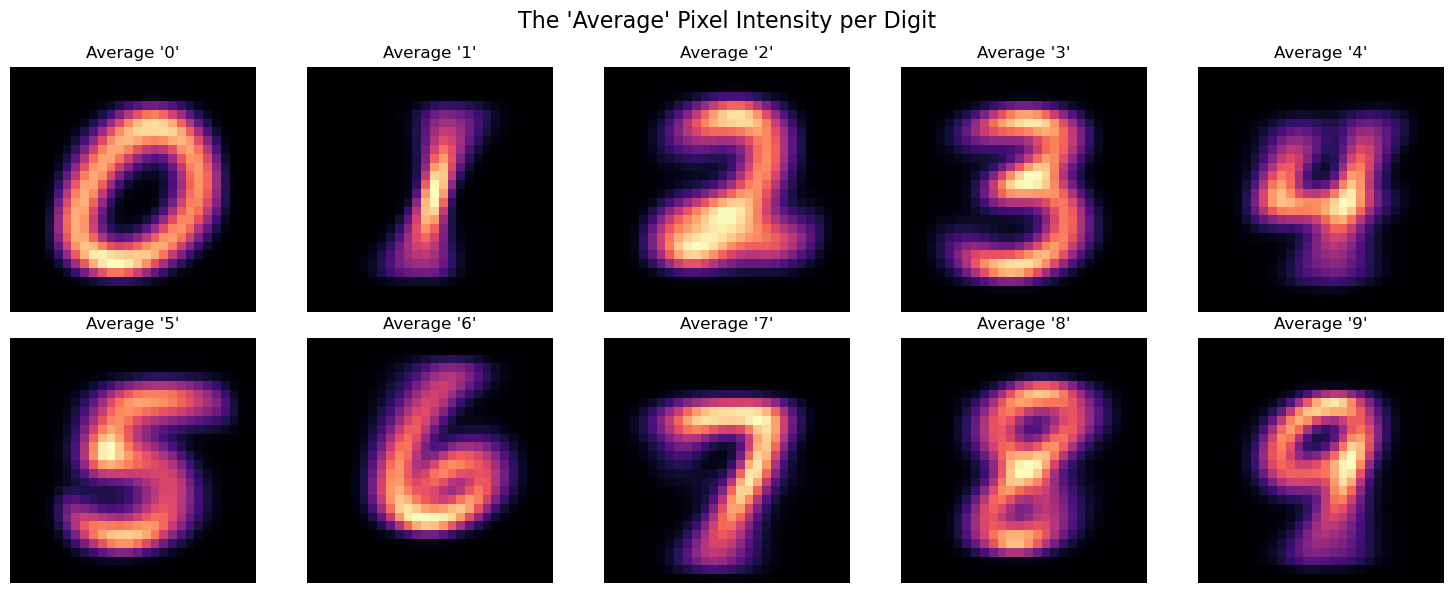

In [5]:
plt.figure(figsize=(15, 6))

for digit in range(10):
    # Filter the dataset for the current digit
    digit_data = X[y == digit]
    
    # Calculate the average pixel values
    avg_image = digit_data.mean(axis=0).values.reshape(28, 28)
    
    plt.subplot(2, 5, digit + 1)
    plt.imshow(avg_image, cmap='magma')
    plt.title(f"Average '{digit}'")
    plt.axis('off')
    
plt.suptitle("The 'Average' Pixel Intensity per Digit", fontsize=16)
plt.tight_layout()
plt.show()

## Step 2: Feature Processing & Engineering

Before feeding our images into an algorithm, we need to optimize the data. 
1. **Normalization:** Machine learning models (especially SVMs and Neural Networks) struggle with large numbers. We will scale our pixel values from `0 - 255` down to `0.0 - 1.0`.
2. **Dimensionality Reduction (PCA):** Images have 784 pixels (features), but many of these pixels are completely useless (like the black edges of the image where nobody writes). We will use Principal Component Analysis to compress the data into fewer, more meaningful features.

In [6]:
# 1. Normalization (Scaling)
print("Normalizing pixel values")
# Dividing by 255 scales all values to be between 0 and 1
X_scaled = X / 255.0

print(f"Max pixel value before: {X.iloc[0].max()}")
print(f"Max pixel value after: {X_scaled.iloc[0].max()}")

Normalizing pixel values
Max pixel value before: 255
Max pixel value after: 1.0


### 2.1 Analyzing Principal Components
PCA creates new "super features" by combining our pixels. But how many of these new features do we actually need to keep? 

Let's fit PCA on our data and plot the **Cumulative Explained Variance**. This will show us exactly how many components we need to retain, say, 95% of the visual information.

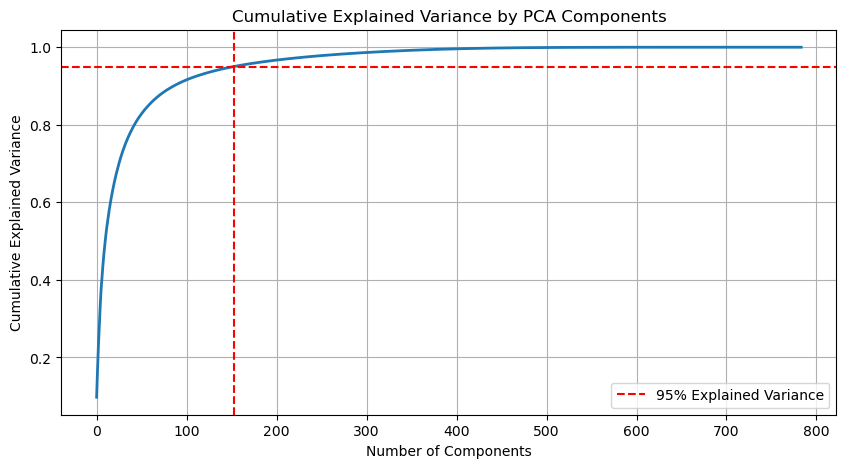

To keep 95% of the information, we only need 153 components (down from 784!)


In [7]:
from sklearn.decomposition import PCA

# Fit PCA on the scaled data without reducing dimensions yet
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot the variance curve
plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.axvline(x=np.argmax(cumulative_variance >= 0.95), color='r', linestyle='--')

plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

# Find exact number of components for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95)
print(f"To keep 95% of the information, we only need {n_components_95} components (down from 784!)")

### 2.2 Applying PCA and Visualizing the Reconstruction
The chart above shows a massive mathematical shortcut! We can throw away over 600 pixels and still keep 95% of the core shapes. 

Let's apply this compression. To prove to ourselves that the model can still "see" the digits, we will reconstruct an image from the compressed data and compare it to the original.

Original shape: (42000, 784)
Compressed shape: (42000, 154)


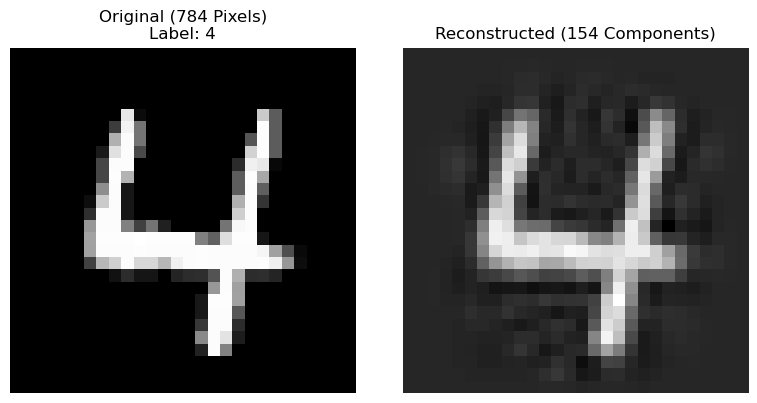

In [8]:
# 1. Apply PCA to keep 95% of the variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape: {X_scaled.shape}")
print(f"Compressed shape: {X_pca.shape}")

# 2. Reconstruct the image from the compressed features
X_reconstructed = pca.inverse_transform(X_pca)

# 3. Plot Original vs. Reconstructed
plt.figure(figsize=(8, 4))

# Pick a random image to display
sample_index = 42 

# Original
plt.subplot(1, 2, 1)
plt.imshow(X_scaled.iloc[sample_index].values.reshape(28, 28), cmap='gray')
plt.title(f"Original (784 Pixels)\nLabel: {y.iloc[sample_index]}")
plt.axis('off')

# Reconstructed
plt.subplot(1, 2, 2)
plt.imshow(X_reconstructed[sample_index].reshape(28, 28), cmap='gray')
plt.title(f"Reconstructed ({X_pca.shape[1]} Components)")
plt.axis('off')

plt.tight_layout()
plt.show()

## Step 3: Implement Machine Learning Methods

Now we will build our predictive models. We will test two distinct algorithms to see which performs best on our engineered data:
1. **Support Vector Machine (SVM):** Excellent at finding complex, non-linear boundaries.
2. **Random Forest:** An ensemble method that builds hundreds of decision trees and averages their votes.

First, we will split our PCA-compressed data into a training set (80%) and a validation set (20%) so we can score our models locally before submitting to Kaggle.

In [9]:
from sklearn.model_selection import train_test_split

# Split the PCA-compressed data (X_pca) and the labels (y)
X_train, X_val, y_train, y_val = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} images")
print(f"Validation set (Holdout): {X_val.shape[0]} images")
print(f"Number of features per image: {X_train.shape[1]} \n784 dimensions to 154!!!\n All thanks to PCA")

Training set: 33600 images
Validation set (Holdout): 8400 images
Number of features per image: 154 
784 dimensions to 154!!!
 All thanks to PCA


### 3.0 Why Not a Linear Classifier? Proving the Data is Not Linearly Separable

Before jumping to powerful kernels, let's first ask: *can a simple straight line (or hyperplane) separate our digits?*

A **Linear SVM** (`kernel='linear'`) tries to find a flat decision boundary in the feature space. If the classes overlap or are arranged in complex clusters, no straight line can separate them — and accuracy will suffer.

We will demonstrate this in two ways:
1. **Visually:** Project the data onto 2 PCA components and plot the classes — if they overlap, the data is not linearly separable.
2. **Empirically:** Train a Linear SVM and compare its accuracy to the RBF kernel SVM.

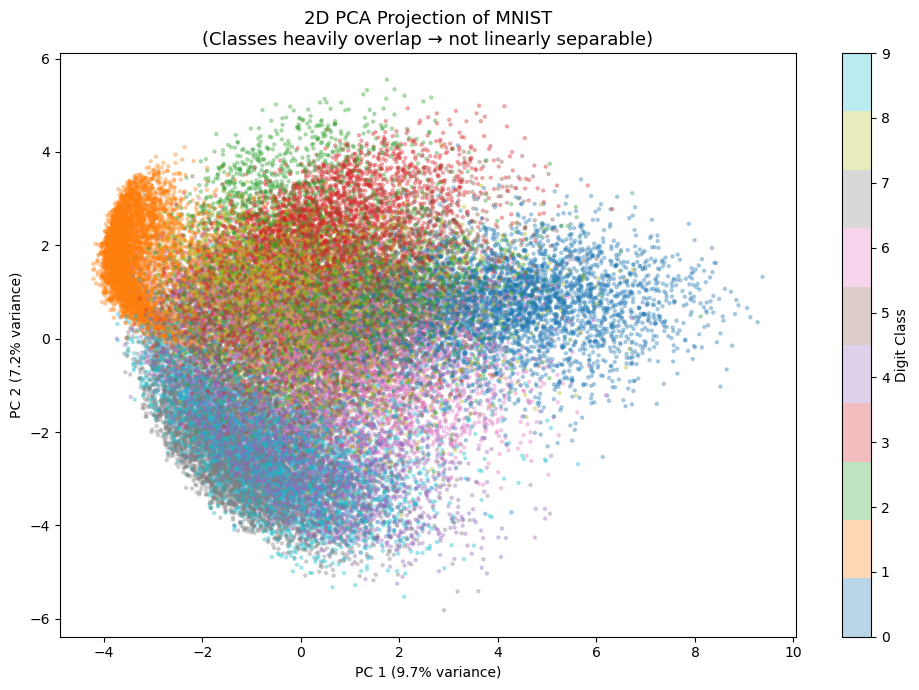

Notice how the digit clusters heavily overlap in 2D space.
No single straight line can cleanly divide even one digit from the rest.


In [10]:
# --- Visual Proof: 2D PCA Scatter Plot ---
# Project down to just 2 components so we can draw a 2D plot
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='tab10', alpha=0.3, s=5)
plt.colorbar(scatter, label='Digit Class')
plt.title('2D PCA Projection of MNIST\n(Classes heavily overlap → not linearly separable)', fontsize=13)
plt.xlabel(f'PC 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

print("Notice how the digit clusters heavily overlap in 2D space.")
print("No single straight line can cleanly divide even one digit from the rest.")

In [11]:
# --- Empirical Proof: Linear SVM ---
from sklearn.svm import LinearSVC
import time
from sklearn.metrics import accuracy_score

print("Training Linear SVM (no kernel — assumes data is linearly separable)...")
linear_svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)

start_time = time.time()
linear_svm.fit(X_train, y_train)
linear_svm_time = time.time() - start_time
print(f"Linear SVM training completed in {linear_svm_time:.2f} seconds.")

linear_preds = linear_svm.predict(X_val)
linear_accuracy = accuracy_score(y_val, linear_preds)



Training Linear SVM (no kernel — assumes data is linearly separable)...


Linear SVM training completed in 8.94 seconds.


### 3.1 Model 1: Support Vector Machine (SVM)
We will initialize an SVM with an RBF (Radial Basis Function) kernel. Because we compressed the data from 784 pixels down to ~154 components using PCA, this training process will be significantly faster than using the raw images.

In [12]:
import time
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

print("Training Support Vector Machine (SVM)...")
# Using our tried-and-true RBF kernel
svm_model = SVC(kernel='rbf', C=10, gamma='scale')

start_time = time.time()
svm_model.fit(X_train, y_train)
svm_time = time.time() - start_time
print(f"SVM Training completed in {svm_time:.2f} seconds.")

# Evaluate on the validation set
print("Evaluating SVM...")
svm_preds = svm_model.predict(X_val)
svm_accuracy = accuracy_score(y_val, svm_preds)

print(f"\n🏆 SVM Validation Accuracy: {svm_accuracy:.2%}")

Training Support Vector Machine (SVM)...
SVM Training completed in 15.62 seconds.
Evaluating SVM...

🏆 SVM Validation Accuracy: 98.20%


In [13]:
print(f"\n📏 Linear SVM Validation Accuracy: {linear_accuracy:.2%}")
print(f"\n--- Accuracy Comparison ---")
print(f"  Linear SVM (no kernel):  {linear_accuracy:.2%}  ← limited by linear boundary")
print(f"  RBF SVM    (with kernel): 98.20%  ← maps data to higher-dim space where it is separable")
print(f"\n  Gap: {(svm_accuracy - linear_accuracy)*100:.2f} percentage points")
print("\nConclusion: The RBF kernel wins because it implicitly maps the data into a")
print("higher-dimensional space where the classes BECOME linearly separable.")


📏 Linear SVM Validation Accuracy: 90.98%

--- Accuracy Comparison ---
  Linear SVM (no kernel):  90.98%  ← limited by linear boundary
  RBF SVM    (with kernel): 98.20%  ← maps data to higher-dim space where it is separable

  Gap: 7.23 percentage points

Conclusion: The RBF kernel wins because it implicitly maps the data into a
higher-dimensional space where the classes BECOME linearly separable.


### 3.2 Model 2: Random Forest
Next, we will try a Random Forest Classifier. This model handles data very differently than an SVM, relying on a "wisdom of the crowds" approach using 100 distinct decision trees.

In [14]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest Classifier...")
# n_estimators=100 means we are planting 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start_time = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time
print(f"Random Forest Training completed in {rf_time:.2f} seconds.")

# Evaluate on the validation set
print("Evaluating Random Forest...")
rf_preds = rf_model.predict(X_val)
rf_accuracy = accuracy_score(y_val, rf_preds)

print(f"\n🌲 Random Forest Validation Accuracy: {rf_accuracy:.2%}")

Training Random Forest Classifier...
Random Forest Training completed in 1.73 seconds.
Evaluating Random Forest...

🌲 Random Forest Validation Accuracy: 94.30%


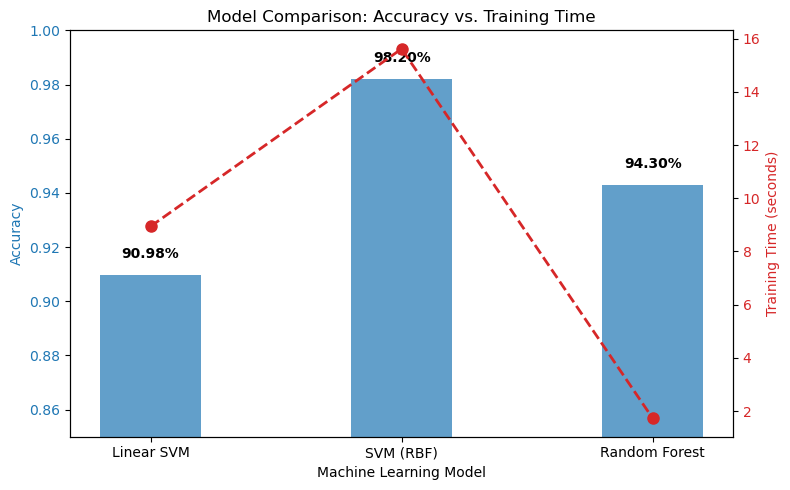

In [15]:
# Let's plot a quick comparison for the report!
models = [
    'Linear SVM',
    'SVM (RBF)', 
    'Random Forest'
]
accuracies = [
    linear_accuracy,
    svm_accuracy,
    rf_accuracy
]
times = [
    linear_svm_time,
    svm_time, 
    rf_time
]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Accuracy (Bar chart)
color = 'tab:blue'
ax1.set_xlabel('Machine Learning Model')
ax1.set_ylabel('Accuracy', color=color)
bars = ax1.bar(models, accuracies, color=color, alpha=0.7, width=0.4)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0.85, 1.0) # Zoom in to see the difference

# Add accuracy labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.2%}", ha='center', va='bottom', fontweight='bold')

# Plot Time taken (Line chart on secondary Y axis)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Training Time (seconds)', color=color)  
ax2.plot(models, times, color=color, marker='o', linestyle='dashed', linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Model Comparison: Accuracy vs. Training Time')
plt.tight_layout()
plt.show()

## Step 4: Hyperparameter Tuning

In the previous step, we used the default settings for our SVM (`C=10`, `gamma='scale'`). Now, we will use `GridSearchCV` to scientifically find the mathematically optimal parameters.

To save compute time, we will perform this search on a random subset of 2,000 training images. Once we identify the best parameters, we will train our final model using those exact settings on the full dataset.

In [16]:
from sklearn.model_selection import GridSearchCV
import time

# 1. Take a small subset of the training data for faster tuning
subset_size = 2000
X_train_tune = X_train[:subset_size]
y_train_tune = y_train[:subset_size]

# 2. Define the "grid" of parameters we want to test
# We will test C values of 0.1, 1, and 10.
# We will test Gamma values of 'scale', 0.01, and 0.1.
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1]
}

# 3. Initialize the Grid Search
# cv=3 means it will do 3-fold cross-validation for every combination
# n_jobs=-1 tells your computer to use all of its CPU cores to run this faster
grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=3, scoring='accuracy', verbose=2, n_jobs=-1)

print(f"Starting Grid Search on {subset_size} samples...")
start_time = time.time()

# 4. Run the search!
grid_search.fit(X_train_tune, y_train_tune)

print(f"\nGrid Search completed in {time.time() - start_time:.2f} seconds.")
print(f"🏆 Best Parameters found: {grid_search.best_params_}")
print(f"📈 Best Cross-Validation Accuracy (on subset): {grid_search.best_score_:.2%}")

Starting Grid Search on 2000 samples...
Fitting 3 folds for each of 9 candidates, totalling 27 fits


[CV] END ....................................C=10, gamma=0.1; total time=   0.3s
[CV] END ...................................C=10, gamma=0.01; total time=   0.2s
[CV] END ...................................C=10, gamma=0.01; total time=   0.2s
[CV] END ....................................C=1, gamma=0.01; total time=   0.2s
[CV] END ....................................C=1, gamma=0.01; total time=   0.2s
[CV] END ..................................C=10, gamma=scale; total time=   0.3s
[CV] END ...................................C=1, gamma=scale; total time=   0.3s
[CV] END ..................................C=10, gamma=scale; total time=   0.3s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.4s
[CV] END ..................................C=10, gamma=scale; total time=   0.3s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.4s
[CV] END .................................C=0.1, gamma=scale; total time=   0.4s
[CV] END ...................

### 4.1 Training the Optimized Model
Now that `GridSearchCV` has identified the best combination of `C` and `gamma`, we will extract that perfectly tuned model and train it on our **entire** 33,000-image training set. Then, we will test it on our validation set to see if our score improved! 

In [17]:
# 1. Grab the best model automatically found by GridSearch
best_svm_model = grid_search.best_estimator_

# 2. Train this optimized model on the FULL training set
print(f"Training optimized SVM ({grid_search.best_params_}) on the full dataset...")
start_time = time.time()
best_svm_model.fit(X_train, y_train)
print(f"Training completed in {time.time() - start_time:.2f} seconds.")

# 3. Evaluate it on our holdout Validation set
print("Evaluating optimized model...")
optimized_preds = best_svm_model.predict(X_val)
optimized_accuracy = accuracy_score(y_val, optimized_preds)

print(f"\n🚀 Final Optimized SVM Accuracy: {optimized_accuracy:.2%}")

# Quick comparison against our baseline from Step 3
improvement = optimized_accuracy - svm_accuracy
if improvement > 0:
    print(f"We improved our accuracy by {improvement:.4f} points!")
else:
    print("Our baseline was already optimal (or very close to it)!")

Training optimized SVM ({'C': 10, 'gamma': 'scale'}) on the full dataset...
Training completed in 16.87 seconds.
Evaluating optimized model...

🚀 Final Optimized SVM Accuracy: 98.20%
Our baseline was already optimal (or very close to it)!


In [18]:
del best_svm_model , rf_model , linear_svm , svm_model

## 5. Deep Learning Techniques
### 5.1 Model 1: Simple Neural Network 


In [19]:
import torch
from torch.utils.data import DataLoader,random_split
from MNISTDataset import MNISTDataset

mnist_dataset = MNISTDataset(X_scaled.values,y.values)

batch_size = 64


total_size = len(mnist_dataset)
train_size = int(0.7 * total_size) # 70% for training
test_size = int(0.2 * total_size)  # 20% for testing
val_size = total_size - train_size - test_size # 10% for validation

train_dataset, test_dataset ,val_dataset = random_split(mnist_dataset, [train_size, test_size, val_size])


batch_size = 64
# Training loader needs shuffling to learn effectively
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# Validation loader doesn't need shuffling
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
# Validation loader doesn't need shuffling
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



In [20]:
from SimpleNeuralNetwork import SNN

INPUT_DIM = X_scaled.values.shape[1]
HIDDEN_DIM = 200
OUTPUT_DIM = 10

device = torch.device('cuda' if torch.cuda.is_available() == True else 'cpu')
learning_rate = 1e-4
epochs = 5

In [21]:
import torch.nn as nn
snn_model = SNN(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM
).to(device=device)

__criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    snn_model.parameters(),
    lr=learning_rate
)


##### Training Simple Neural Network


In [22]:
from ModelTrainer import SNNTrainer
snn_trainer = SNNTrainer(
    model=snn_model,
    optimizer=optimizer,
    criterion=nn.CrossEntropyLoss(),
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    save_path="best_snn_weights.pth"
)
snn_trainer.train(epochs=10)

Starting training on cuda for 10 epochs...


Epoch 1/10 [Train SNN]: 100%|██████████| 460/460 [00:01<00:00, 247.05batch/s, loss=0.3888]


End of Epoch [1/10]
Train Metrics: {'loss': 1.0058481165248414, 'accuracy': 79.6353617469982}
Val Metrics:   {'loss': 0.5114829991803025, 'accuracy': 88.19328731254463}
*** Validation loss improved (inf --> 0.5115). Saving model! ***
------------------------------------------------------------


Epoch 2/10 [Train SNN]: 100%|██████████| 460/460 [00:01<00:00, 292.03batch/s, loss=0.2247]


End of Epoch [2/10]
Train Metrics: {'loss': 0.4324028237034445, 'accuracy': 88.90098302663355}
Val Metrics:   {'loss': 0.36776016291343805, 'accuracy': 90.45465365389192}
*** Validation loss improved (0.5115 --> 0.3678). Saving model! ***
------------------------------------------------------------


...

End of Epoch [8/10]
Train Metrics: {'loss': 0.2527249167956736, 'accuracy': 92.86370284703561}
Val Metrics:   {'loss': 0.2660803295897715, 'accuracy': 92.52558914544156}
*** Validation loss improved (0.2701 --> 0.2661). Saving model! ***
------------------------------------------------------------


Epoch 9/10 [Train SNN]: 100%|██████████| 460/460 [00:01<00:00, 294.02batch/s, loss=0.2965]


End of Epoch [9/10]
Train Metrics: {'loss': 0.2447201748257098, 'accuracy': 93.08139732643967}
Val Metrics:   {'loss': 0.26286858783075306, 'accuracy': 92.54939300166627}
*** Validation loss improved (0.2661 --> 0.2629). Saving model! ***
------------------------------------------------------------


Epoch 10/10 [Train SNN]: 100%|██████████| 460/460 [00:01<00:00, 286.55batch/s, loss=0.1050]


End of Epoch [10/10]
Train Metrics: {'loss': 0.23692548925300008, 'accuracy': 93.3705228068982}
Val Metrics:   {'loss': 0.2567361534544916, 'accuracy': 92.69221613901452}
*** Validation loss improved (0.2629 --> 0.2567). Saving model! ***
------------------------------------------------------------


In [23]:
del snn_model

In [24]:
import torch

def evaluate_model(model, test_loader, criterion, device):
    """
    Evaluates a trained PyTorch model on a test dataset.
    
    Args:
        model (nn.Module): The trained PyTorch model to evaluate.
        test_loader (DataLoader): The DataLoader containing the test data.
        criterion: The loss function to use (e.g., nn.CrossEntropyLoss()).
        device (torch.device): 'cuda' or 'cpu'.
        
    Returns:
        tuple: (avg_test_loss, test_accuracy, all_predictions, all_true_labels)
    """
    # CRITICAL: Set the model to evaluation mode
    model.eval()
    
    # model.__class__.__name__ dynamically gets the name of your architecture (e.g., 'SNN' or 'VAE')
    print(f"Evaluating [{model.__class__.__name__}] on the Test Set...\n")

    test_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_true_labels = []

    # Disable gradient calculation for testing
    with torch.no_grad():
        for batch_X, batch_y in test_loader: 
            # Move data to GPU/CPU
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Forward pass
            outputs = model(batch_X)
            
            # Calculate loss
            loss = criterion(outputs, batch_y)
            test_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
            # Save predictions for later analysis
            all_predictions.extend(predicted.cpu().numpy())
            all_true_labels.extend(batch_y.cpu().numpy())

    # --- Final Results ---
    avg_test_loss = test_loss / len(test_loader)
    test_accuracy = 100 * correct / total

    print("="*45)
    print(f" FINAL TEST METRICS: {model.__class__.__name__} ")
    print("="*45)
    print(f" Test Loss:     {avg_test_loss:.4f}")
    print(f" Test Accuracy: {test_accuracy:.2f}%")
    print("="*45)
    
    return avg_test_loss, test_accuracy, all_predictions, all_true_labels

In [25]:

best_model = SNN(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)

# Load the weights we saved during the validation phase
best_model.load_state_dict(torch.load('best_mnist_model.pth'))
avg_test_loss, test_accuracy, all_predictions, all_true_labels = evaluate_model(
    model=best_model,
    test_loader=test_loader,
    criterion=nn.CrossEntropyLoss(),
    device=device
)
print("Testing Finished")

/tmp/ipykernel_3317984/309042276.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load('best_mnist_model.pth'))


Evaluating [SNN] on the Test Set...

 FINAL TEST METRICS: SNN 
 Test Loss:     0.2333
 Test Accuracy: 93.19%
Testing Finished


              precision    recall  f1-score   support

           0       0.97      0.97      0.97       816
           1       0.97      0.98      0.97       922
           2       0.96      0.90      0.92       843
           3       0.91      0.91      0.91       823
           4       0.93      0.93      0.93       840
           5       0.91      0.90      0.90       785
           6       0.96      0.98      0.97       796
           7       0.95      0.94      0.95       885
           8       0.87      0.91      0.89       845
           9       0.89      0.91      0.90       845

    accuracy                           0.93      8400
   macro avg       0.93      0.93      0.93      8400
weighted avg       0.93      0.93      0.93      8400



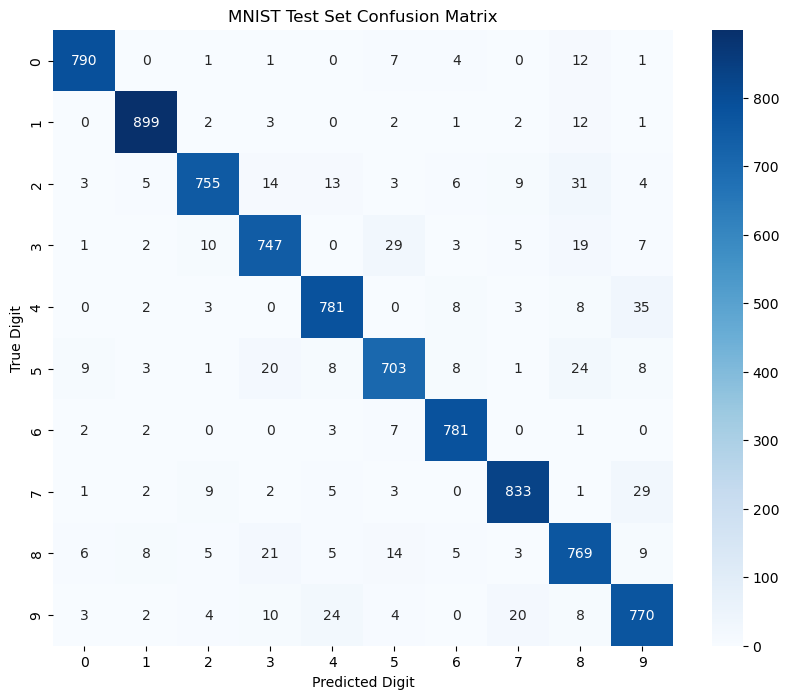

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Print a detailed text report
print(classification_report(all_true_labels, all_predictions))

# Plot a visual confusion matrix
cm = confusion_matrix(all_true_labels, all_predictions)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')
plt.title('MNIST Test Set Confusion Matrix')
plt.show()

Total misclassified images: 572


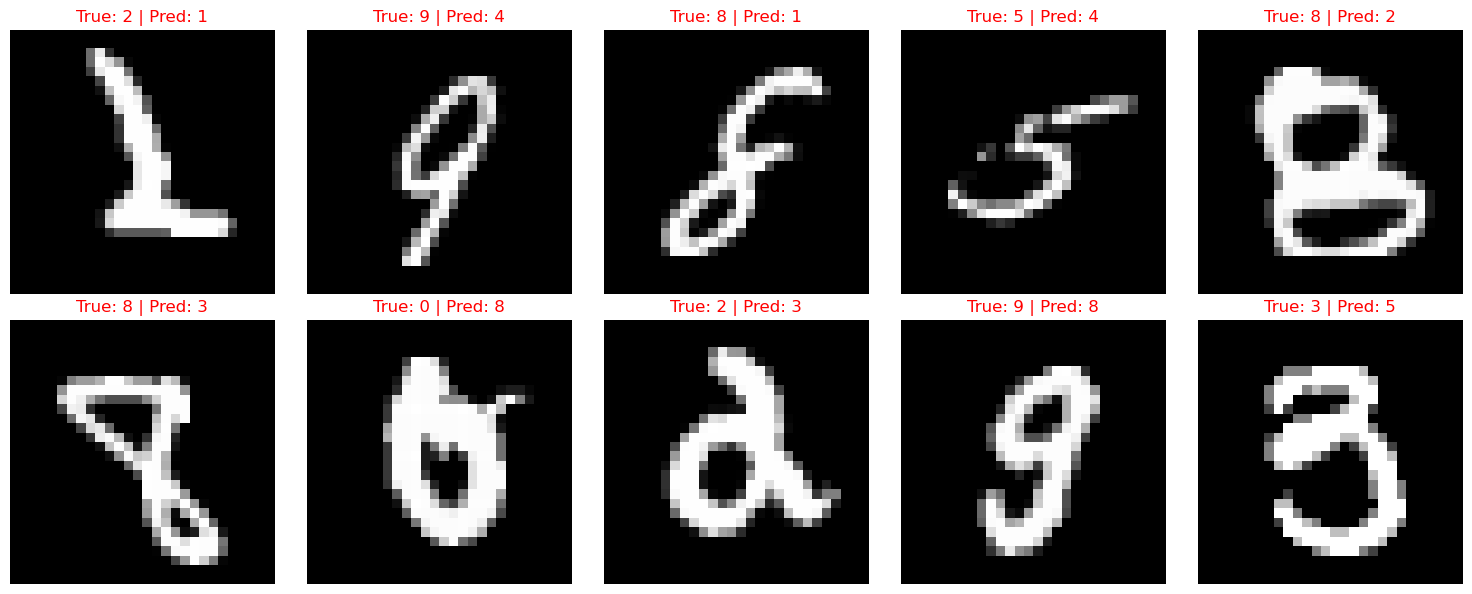

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Convert our tracking lists to NumPy arrays for easy filtering
predictions = np.array(all_predictions)
truths = np.array(all_true_labels)

# 2. Find all the indices where the prediction was WRONG
misclassified_indices = np.where(predictions != truths)[0]
print(f"Total misclassified images: {len(misclassified_indices)}")

# 3. Set up a grid to show the first 10 mistakes
num_to_show = 10
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel() # Flatten the axes array for easy iteration

for i in range(min(num_to_show, len(misclassified_indices))):
    # Get the index of the misclassified image
    idx = misclassified_indices[i]
    
    # Get the labels
    true_label = truths[idx]
    pred_label = predictions[idx]
    
    # Grab the original image tensor from the test dataset
    # (Assuming your dataset is named 'test_dataset')
    image_tensor, _ = test_dataset[idx] 
    
    # Our neural network takes a flat 784-item array. 
    # To plot it, we must reshape it back into a 28x28 grid.
    image_2d = image_tensor.view(28, 28).cpu().numpy()
    
    # Plot the image
    axes[i].imshow(image_2d, cmap='gray')
    
    # Add a title showing what went wrong (in red to highlight the error)
    axes[i].set_title(f"True: {true_label} | Pred: {pred_label}", color='red')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [28]:
del best_model

In [29]:
from ModelTrainer import VAETrainer
from VariationalAutoEncoder import VAE,vae_loss
vae_model = VAE().to(device=device)

optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)

vae_trainer = VAETrainer(
    model=vae_model,
    optimizer=optimizer,
    vae_loss_fn=vae_loss,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    save_path="best_vae_weights.pth"
)

vae_trainer.train(
    epochs=30
)







Starting training on cuda for 30 epochs...


Epoch 1/30 [Train VAE]: 100%|██████████| 460/460 [00:02<00:00, 201.26batch/s, loss=3355.7407] 


End of Epoch [1/30]
Train Metrics: {'loss': 10923.609281589674}
Val Metrics:   {'loss': 8622.033173532196}
*** Validation loss improved (inf --> 8622.0332). Saving model! ***
------------------------------------------------------------


Epoch 2/30 [Train VAE]: 100%|██████████| 460/460 [00:02<00:00, 207.51batch/s, loss=2762.3762]


End of Epoch [2/30]
Train Metrics: {'loss': 8066.676457944123}
Val Metrics:   {'loss': 7697.647971413352}
*** Validation loss improved (8622.0332 --> 7697.6480). Saving model! ***
------------------------------------------------------------


...

End of Epoch [28/30]
Train Metrics: {'loss': 6658.017256496263}
Val Metrics:   {'loss': 6744.097241950758}
------------------------------------------------------------


Epoch 29/30 [Train VAE]: 100%|██████████| 460/460 [00:02<00:00, 210.18batch/s, loss=2452.5935]


End of Epoch [29/30]
Train Metrics: {'loss': 6648.725063158118}
Val Metrics:   {'loss': 6750.991099964489}
------------------------------------------------------------


Epoch 30/30 [Train VAE]: 100%|██████████| 460/460 [00:02<00:00, 205.13batch/s, loss=2489.3176]


End of Epoch [30/30]
Train Metrics: {'loss': 6645.219854470958}
Val Metrics:   {'loss': 6728.947176846591}
*** Validation loss improved (6729.8100 --> 6728.9472). Saving model! ***
------------------------------------------------------------


In [30]:
vae_trainer.evaluate(test_loader)

Evaluating [VAE] on the Test Set...

 FINAL TEST METRICS: VAE 
 Test Loss (Reconstruction + KL): 6720.1253


(6720.125319972183,
 [array([0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.   